In [1]:
import torch as tor
import timm as tim
import matplotlib 
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
random.seed(67) #for reproduce

In [2]:
import torchvision as tv
from torchvision import transforms as tr

In [3]:
m=(0.5071, 0.4867, 0.4408)
s=(0.2675, 0.2565, 0.2761)
traint=tr.Compose(
    [
        tr.RandomCrop(32,padding=4), #because cifar are 32x32 images 
        tr.RandomHorizontalFlip(),
        tr.Resize((224,224)),
        tr.ToTensor(),
        tr.Normalize(mean=m,std=s)
    ]
)
testt=tr.Compose(
    [
        tr.Resize((224,224)),
        tr.ToTensor(),
        tr.Normalize(mean=m,std=s)
    ]
)

In [4]:
traind=tv.datasets.ImageFolder("/kaggle/input/datasets/melikechan/cifar100/cifar100/train",transform=traint)
testd=tv.datasets.ImageFolder("/kaggle/input/datasets/melikechan/cifar100/cifar100/test",transform=testt)

In [5]:
ind=list(range(len(traind)))
random.shuffle(ind)

In [6]:
dev=tor.device("cuda")

# loading pretrained models

In [7]:
models={}

In [8]:
teach=tv.models.resnet18(weights=None)
teach.fc = tor.nn.Linear(teach.fc.in_features, 100)
state = tor.load("/kaggle/input/models/totallyapoorv/resnetoncifar100/pytorch/default/1/resnetall.pth", map_location="cpu")
teach.load_state_dict(state)
teach=teach.to(dev)
teach.eval()
print("Loaded teacher")

Loaded teacher


In [9]:
models['resnet']=teach

In [10]:
for i in ['10','25','50','100']:
    models[f'vit_{i}pct']=tim.create_model("vit_tiny_patch16_224",pretrained=False,num_classes=100)
    models[f'vit_{i}pct'].load_state_dict(tor.load(f"/kaggle/input/notebooks/totallyapoorv/researchs1/vit_{i}pct.pth"))
    models[f'vit_{i}pct']=models[f'vit_{i}pct'].to(dev)
    models[f'vit_{i}pct'].eval()

In [11]:
for i in ['10','25','50','100']:
    models[f'deit_{i}pct']=tim.create_model("vit_tiny_patch16_224",pretrained=False,num_classes=100)
    models[f'deit_{i}pct'].load_state_dict(tor.load(f"/kaggle/input/notebooks/totallyapoorv/researchs2/vit_{i}pct.pth"))
    models[f'deit_{i}pct']=models[f'deit_{i}pct'].to(dev)
    models[f'deit_{i}pct'].eval()

In [12]:
models.keys()

dict_keys(['resnet', 'vit_10pct', 'vit_25pct', 'vit_50pct', 'vit_100pct', 'deit_10pct', 'deit_25pct', 'deit_50pct', 'deit_100pct'])

# ATTENTION ANALYSIS

## choosing 10 random images

In [13]:
chosen_ids = [
    6880,
    6997,
    6094,
    484,
    5985,
    2289,
    1712,
    7157,
    7154,
    93
] #these are picked from the strongest and weakest classes of the models

In [14]:
def analyse(model,idt):
    img, label = testd[chosen_ids[idt]]
    img = img.unsqueeze(0).to(dev)
    # disable fused attention
    for block in model.blocks:
        block.attn.fused_attn = False
    # capture input to final attention block
    saved = {}
    def hook_fn(module, inp):
        saved["x"] = inp[0].detach()
    handle = model.blocks[-1].attn.register_forward_pre_hook(hook_fn)
    with tor.no_grad():
        _ = model(img)
    handle.remove()
    # reconstruct attention
    x = saved["x"]
    attn_mod = model.blocks[-1].attn
    B, N, C = x.shape
    qkv = attn_mod.qkv(x)
    qkv = qkv.reshape(B,N,3,attn_mod.num_heads,attn_mod.head_dim)
    qkv = qkv.permute(2,0,3,1,4)
    q, k, v = qkv.unbind(0)
    q = q * attn_mod.scale
    attn = q @ k.transpose(-2,-1)
    attn = attn.softmax(dim=-1)
    
    # CLS token attention
    cls_attn = attn[0,:,0,:]
    cls_attn = cls_attn.mean(dim=0)
    cls_attn = cls_attn[1:]
    cls_attn = cls_attn.reshape(14,14)
    
    # upscale to image size
    
    heatmap = cls_attn.unsqueeze(0).unsqueeze(0)
    heatmap = F.interpolate(heatmap,size=(224,224),mode="bilinear",align_corners=False)
    heatmap = heatmap.squeeze()
    heatmap = heatmap.cpu()
    heatmap = heatmap - heatmap.min()
    heatmap = heatmap / heatmap.max()

    # denormalize image
   
    display_img = img.squeeze(0).cpu()
    display_img[0] = display_img[0]*0.2675 + 0.5071
    display_img[1] = display_img[1]*0.2565 + 0.4867
    display_img[2] = display_img[2]*0.2761 + 0.4408
    display_img = display_img.clamp(0,1)
    display_img = display_img.permute(1,2,0)
    
    # plot
    
    return heatmap,display_img



In [15]:
import torch
import torch.nn.functional as F

def get_resnet_heatmap(model, idt):
    img, label = testd[chosen_ids[idt]]
    img = img.unsqueeze(0).to(dev)
    activations = {}
    gradients = {}
    def forward_hook(module, inp, out):
        activations["value"] = out
    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]
    handle_f = model.layer4[-1].register_forward_hook(forward_hook)
    handle_b = model.layer4[-1].register_full_backward_hook(backward_hook)
    model.zero_grad()
    output = model(img)
    pred = output.argmax(dim=1)
    re = output[0, pred]
    re.backward()
    acts = activations["value"]
    grads = gradients["value"]
    weights = grads.mean(dim=(2,3), keepdim=True)
    cam = (weights * acts).sum(dim=1)
    cam = F.relu(cam)
    cam = cam.squeeze()
    cam = cam.cpu()
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    cam = F.interpolate(
        cam.unsqueeze(0).unsqueeze(0),
        size=(224,224),
        mode="bilinear",
        align_corners=False
    )
    cam = cam.squeeze()
    handle_f.remove()
    handle_b.remove()
    display_img = img.squeeze(0).cpu()
    display_img[0] = display_img[0]*0.2675 + 0.5071
    display_img[1] = display_img[1]*0.2565 + 0.4867
    display_img[2] = display_img[2]*0.2761 + 0.4408
    display_img = display_img.clamp(0,1)
    display_img = display_img.permute(1,2,0)
    
    display_img[0] = display_img[0] * 0.2675 + 0.5071
    display_img[1] = display_img[1] * 0.2565 + 0.4867
    display_img[2] = display_img[2] * 0.2761 + 0.4408
    
    display_img = display_img.clamp(0, 1)
    return (cam,display_img)

In [16]:
models.keys()

dict_keys(['resnet', 'vit_10pct', 'vit_25pct', 'vit_50pct', 'vit_100pct', 'deit_10pct', 'deit_25pct', 'deit_50pct', 'deit_100pct'])

In [17]:
import os
import matplotlib.pyplot as plt

os.makedirs("attention_outputs", exist_ok=True)

pcts = ["10", "25", "50", "100"]

for img_idx in range(9):
    
    fig, axes = plt.subplots(4, 4, figsize=(20, 20))

    for row, pct in enumerate(pcts):
        
        vit_heatmap, display_img = analyse(models[f"vit_{pct}pct"], img_idx)
        resnet_heatmap, _ = get_resnet_heatmap(models["resnet"], img_idx)
        deit_heatmap, _ = analyse(models[f"deit_{pct}pct"], img_idx)

        axes[row, 0].imshow(display_img)
        axes[row, 0].set_title(f"Original\n{pct}%")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(display_img)
        axes[row, 1].imshow(vit_heatmap.detach().cpu().numpy(), cmap="jet", alpha=0.4)
        axes[row, 1].set_title(f"ViT {pct}%")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(display_img)
        axes[row, 2].imshow(resnet_heatmap.detach().cpu().numpy(), cmap="jet", alpha=0.4)
        axes[row, 2].set_title("ResNet18")
        axes[row, 2].axis("off")

        axes[row, 3].imshow(display_img)
        axes[row, 3].imshow(deit_heatmap.detach().cpu().numpy(), cmap="jet", alpha=0.4)
        axes[row, 3].set_title(f"DeiT {pct}%")
        axes[row, 3].axis("off")

    plt.tight_layout()

    fig.savefig(f"attention_outputs/attention_grid_{img_idx}.png",dpi=300,bbox_inches="tight")

    plt.close(fig)

In [18]:
import matplotlib.pyplot as plt

## SAVING ATTENTION MAPS AS A PDF

In [22]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

pcts = ["10", "25", "50", "100"]

with PdfPages("attention_outputs/all_attention_grids1.pdf") as pdf:
    for img_idx in range(9):
        fig, axes = plt.subplots(4, 4, figsize=(20, 20))

        for row, pct in enumerate(pcts):
            vit_heatmap, display_img = analyse(models[f"vit_{pct}pct"], img_idx)
            resnet_heatmap, _ = get_resnet_heatmap(models["resnet"], img_idx)
            deit_heatmap, _ = analyse(models[f"deit_{pct}pct"], img_idx)

            axes[row, 0].imshow(display_img)
            axes[row, 0].set_title(f"Original\n{pct}%")
            axes[row, 0].axis("off")

            axes[row, 1].imshow(display_img)
            axes[row, 1].imshow(
                vit_heatmap.detach().cpu().numpy(),
                cmap="jet",
                alpha=0.4
            )
            axes[row, 1].set_title(f"ViT {pct}%")
            axes[row, 1].axis("off")

            axes[row, 2].imshow(display_img)
            axes[row, 2].imshow(
                resnet_heatmap.detach().cpu().numpy(),
                cmap="jet",
                alpha=0.4
            )
            axes[row, 2].set_title("ResNet18")
            axes[row, 2].axis("off")

            axes[row, 3].imshow(display_img)
            axes[row, 3].imshow(
                deit_heatmap.detach().cpu().numpy(),
                cmap="jet",
                alpha=0.4
            )
            axes[row, 3].set_title(f"DeiT {pct}%")
            axes[row, 3].axis("off")

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

### hard coded graph from logs of earlier training

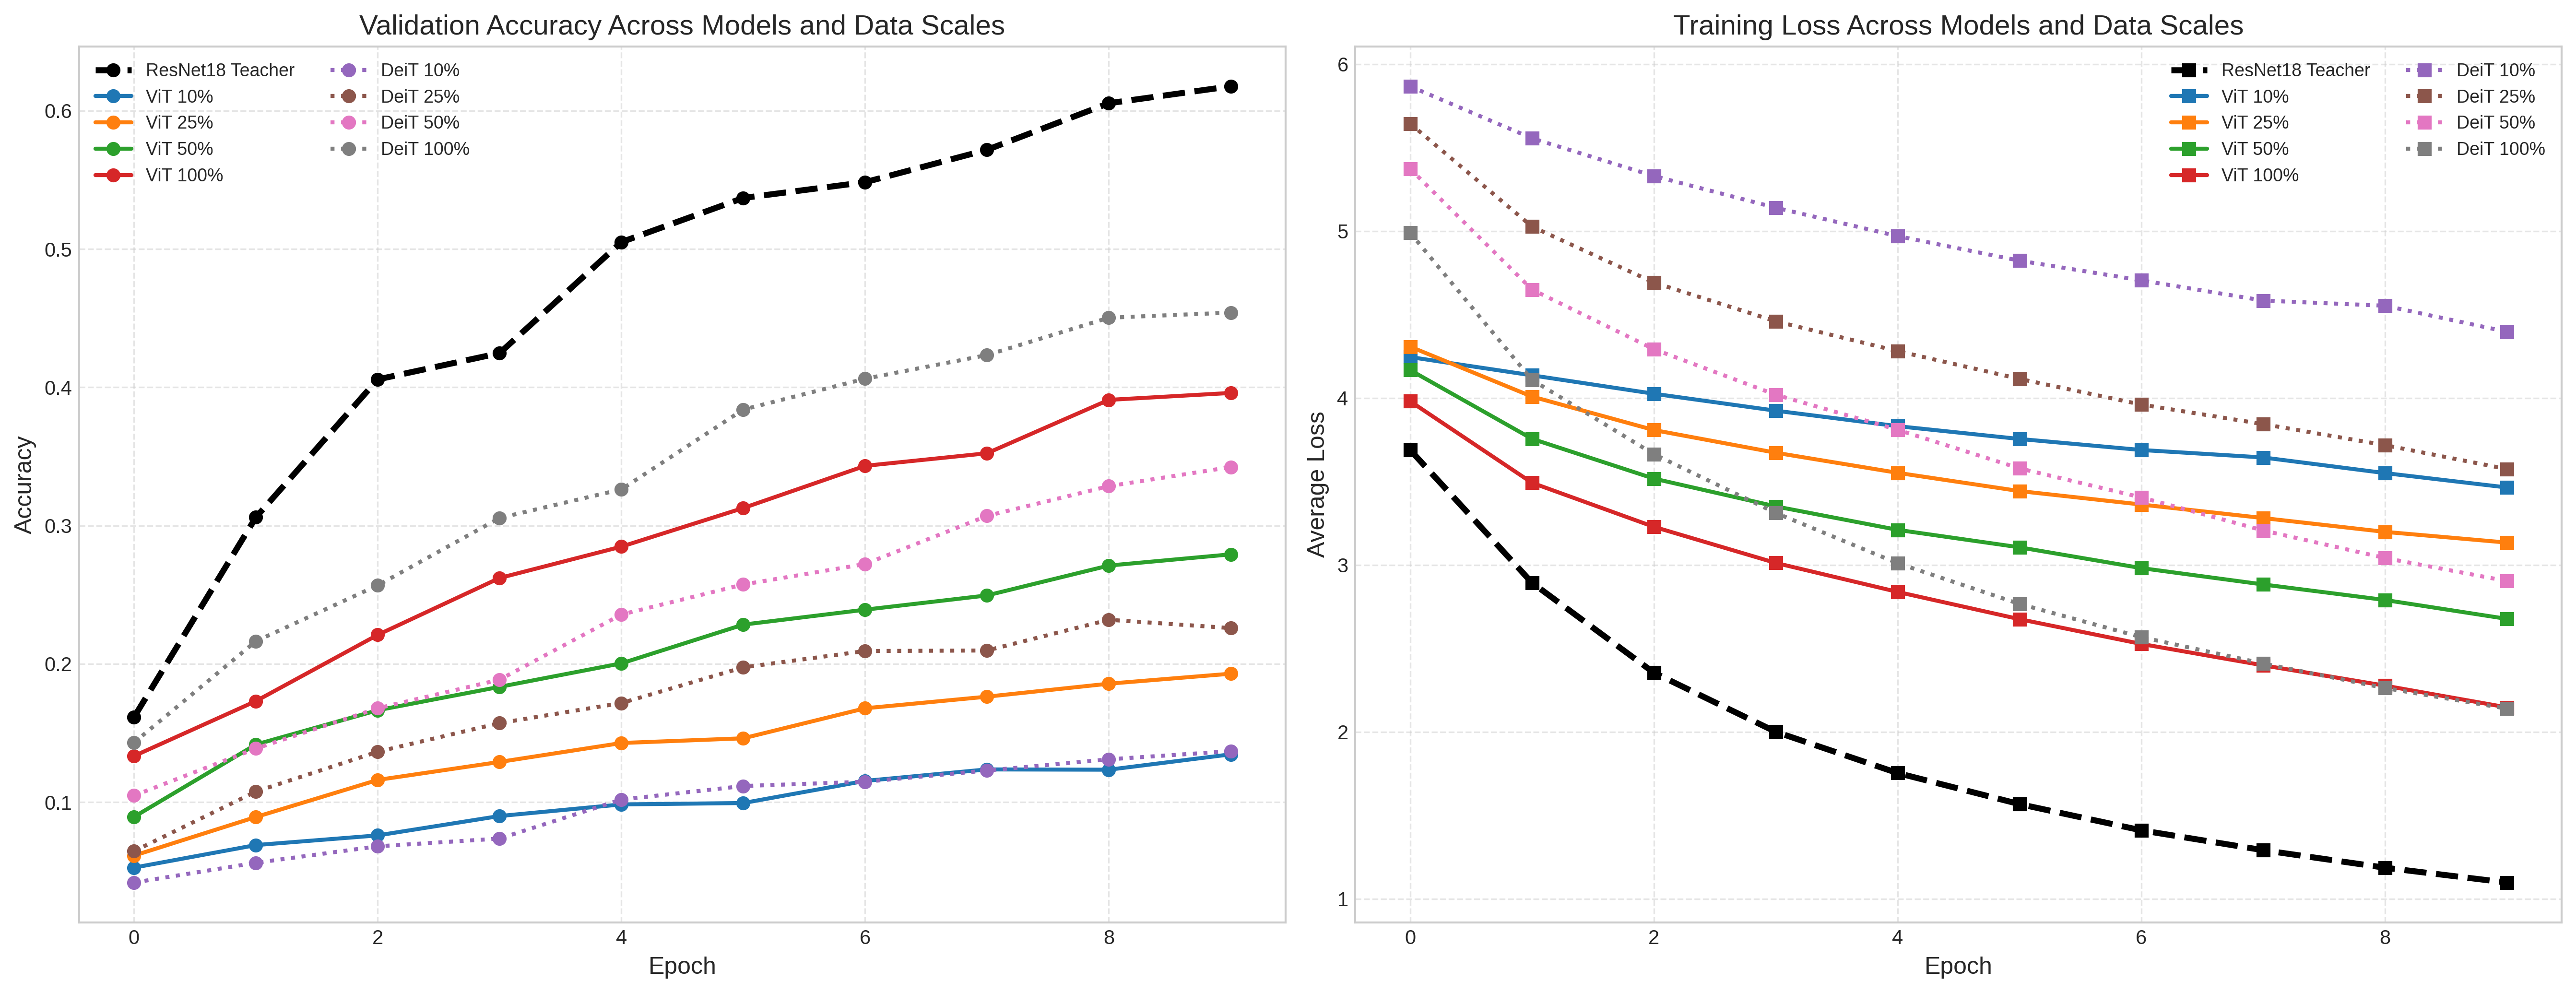

In [20]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

epochs = list(range(10))

teacher_data = {
    "loss": [3.689, 2.894, 2.355, 2.001, 1.754, 1.568, 1.411, 1.292, 1.187, 1.098],
    "acc":  [0.1615, 0.3060, 0.4057, 0.4247, 0.5050, 0.5369, 0.5483, 0.5717, 0.6054, 0.6176]
}

vit_data = {
    "ViT 10%": {
        "loss": [4.245482604714889, 4.136148751536502, 4.0258332717267775, 3.9243178971206087, 3.8315536191191852, 3.7549319810505155, 3.6889282178275193, 3.644140717349475, 3.550587509251848, 3.464518640614763],
        "acc":  [0.0527, 0.0690, 0.0760, 0.0900, 0.0984, 0.0994, 0.1154, 0.1237, 0.1235, 0.1346]
    },
    "ViT 25%": {
        "loss": [4.307753964346283, 4.008823211095771, 3.808400723398948, 3.6724855048315868, 3.5521770302130253, 3.4429413846560886, 3.3622586544679134, 3.281292155080912, 3.1984780929526506, 3.134418859773753],
        "acc":  [0.0614, 0.0893, 0.1161, 0.1291, 0.1428, 0.1462, 0.1679, 0.1763, 0.1857, 0.1929]
    },
    "ViT 50%": {
        "loss": [4.167573452605616, 3.755877038706904, 3.5175678498299834, 3.3510685704858103, 3.2105481088009027, 3.1060437771975233, 2.981522557680564, 2.8835218873475212, 2.79046557138643, 2.677434098080296],
        "acc":  [0.0894, 0.1417, 0.1665, 0.1834, 0.2004, 0.2284, 0.2392, 0.2495, 0.2711, 0.2792]
    },
    "ViT 100%": {
        "loss": [3.9807483619436277, 3.4923489663911904, 3.228702048206573, 3.0124343734263155, 2.838880360278937, 2.6756625856889786, 2.527339631791615, 2.399184120128222, 2.2773199156117254, 2.147375154678169],
        "acc":  [0.1334, 0.1731, 0.2210, 0.2621, 0.2848, 0.3127, 0.3432, 0.3523, 0.3909, 0.3959]
    }
}

deit_data = {
    "DeiT 10%": {
        "loss": [5.867, 5.556, 5.330, 5.140, 4.970, 4.823, 4.705, 4.584, 4.553, 4.397],
        "acc":  [0.0419, 0.0562, 0.0681, 0.0737, 0.1019, 0.1117, 0.1148, 0.1229, 0.1310, 0.1369]
    },
    "DeiT 25%": {
        "loss": [5.644, 5.027, 4.692, 4.460, 4.281, 4.115, 3.961, 3.844, 3.718, 3.575],
        "acc":  [0.0646, 0.1077, 0.1365, 0.1572, 0.1717, 0.1975, 0.2093, 0.2097, 0.2319, 0.2259]
    },
    "DeiT 50%": {
        "loss": [5.373, 4.650, 4.293, 4.020, 3.810, 3.579, 3.405, 3.207, 3.042, 2.904],
        "acc":  [0.1048, 0.1388, 0.1679, 0.1886, 0.2357, 0.2574, 0.2722, 0.3070, 0.3285, 0.3423]
    },
    "DeiT 100%": {
        "loss": [4.990, 4.109, 3.664, 3.312, 3.011, 2.767, 2.568, 2.410, 2.263, 2.140],
        "acc":  [0.1431, 0.2164, 0.2568, 0.3055, 0.3262, 0.3839, 0.4062, 0.4233, 0.4503, 0.4540]
    }
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), dpi=300)

# Accuracy plot
ax1.plot(epochs, teacher_data["acc"], marker="o", linewidth=3, linestyle="--", color="black", label="ResNet18 Teacher")

for label, metrics in vit_data.items():
    ax1.plot(epochs, metrics["acc"], marker="o", linewidth=2, label=label)

for label, metrics in deit_data.items():
    ax1.plot(epochs, metrics["acc"], marker="o", linewidth=2, linestyle=":", label=label)

ax1.set_title("Validation Accuracy Across Models and Data Scales", fontsize=14)
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Accuracy", fontsize=12)
ax1.legend(fontsize=9, ncol=2)
ax1.grid(True, linestyle="--", alpha=0.5)

# Loss plot
ax2.plot(epochs, teacher_data["loss"], marker="s", linewidth=3, linestyle="--", color="black", label="ResNet18 Teacher")

for label, metrics in vit_data.items():
    ax2.plot(epochs, metrics["loss"], marker="s", linewidth=2, label=label)

for label, metrics in deit_data.items():
    ax2.plot(epochs, metrics["loss"], marker="s", linewidth=2, linestyle=":", label=label)

ax2.set_title("Training Loss Across Models and Data Scales", fontsize=14)
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Average Loss", fontsize=12)
ax2.legend(fontsize=9, ncol=2)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig(
    "training_comparison_all_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "training_comparison_all_models.pdf",
    bbox_inches="tight"
)

plt.show()